# Directory Settings

> ***ALWAYS RUN THIS CELL FIRST***

Setting Project Directory for Proper Imports

In [1]:
import sys
from pathlib import Path

# Get the absolute path of the parent directory (your root folder)
root_path = str(Path.cwd().parent)

# Add it to sys.path if it isn't already there
if root_path not in sys.path:
    sys.path.append(root_path)
    
print(f"Project Root Path Set to: {root_path}")

Project Root Path Set to: d:\Projects\TTRPG Agent\Crude Version\Refactored


# Data

In [2]:
import os
from src.env import PersistentVars

Parsing data from links or local drives and collecting all relevant data in required folders.
Folder Structure is as follows:

```text

data
|
|___ Game Name (lowercaps)
        |
        |___game_rulebook_handbook_etal.pdf

```


Data is loaded properly to the persistent vector store. The folder structure is as follows:

```text
data
|
|__ vectorDB
|    |__ chromaDB
|
|__ systems.json

```

`systems.json` holds all registered game systems. (Registered implies game system information in the data base)

## Parsing the Data

### Imports

In [3]:
from src.data.config_models import IngestionConfig
from src.data.data_loader import Ingestion

d:\Projects\TTRPG Agent\Crude Version\Refactored\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


### Game Files

Add file paths and URL's here to load SRD or other Game data to the database here.

In [10]:
# Assign Variable values
# Dnd
# source = "https://media.dndbeyond.com/compendium-images/srd/5.2/SRD_CC_v5.2.1.pdf"
# game_name = "Dungeoun and Dragons"
# file_name = "DnD_5.2.1_SRD"


# Blades in the dark
# game_name = "Blades in the Dark"

# srd
# source = "A:\Fargee\pdfcoffee.com_blades-in-the-dark-core-rulebookpdf-pdf-free.pdf"
# file_name = "Blades_in_the_dark_SRD"

# Player Kit
# source = "A:\Fargee\\blades_playerkit_v8_2.pdf"
# file_name = "Blades_in_the_dark_player_kit"


# Laser Feelings
# game_name = "Laser and Feelings"
# source = "A:\Fargee\lasers_and_feelings_rpg.pdf"
# file_name = "Laser_and_feelings.pdf"


# Pathfinder
game_name = "Pathfinder"
source = "https://www.d20pfsrd.com/wp-content/uploads/sites/12/2017/01/PFRPG_SRD.pdf"
file_name = "Pathfinder_srd.pdf"

### Parse / Download data locally to data folder

In [11]:
# Check if data directory exists, else create it
os.makedirs(PersistentVars.DATA_FOLDER, exist_ok=True)

config = IngestionConfig(
    source = source,
    game_name = game_name,
    file_name = file_name
)

ingestor = Ingestion(config)
game_file_path = ingestor.loader.load_data()
game_file_path

WindowsPath('d:/Projects/TTRPG Agent/Crude Version/Refactored/data/pathfinder/pathfinder_srd.pdf.pdf')

## Data to DB Pipeline

### Imports

In [12]:
from langchain_huggingface import HuggingFaceEmbeddings

from src.data.data_pipeline import DataPipelineManager 

### Database Creation / Update

In [13]:
print("Downloading and loading the embedding model...")

embedding_model = HuggingFaceEmbeddings(
    model_name=PersistentVars.EMBBEDDING_MODEL,
    # Route it to the GPU
    model_kwargs={'device': 'cuda'}, 
    # BGE models perform best when cosine similarity is normalized
    encode_kwargs={'normalize_embeddings': True} 
)


# Initialize the orchestrator
pipeline = DataPipelineManager(
    db_path=PersistentVars.DB_PATH, 
    embedding_model=embedding_model
)

# Run the ingestion (it will automatically skip already-processed files)
pipeline.run_pipeline()

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 6606.93it/s]


Connecting to persistent ChromaDB at d:\Projects\TTRPG Agent\Crude Version\Refactored\vectorDB\chromaDB...
Found 5 game files!
The Files are:
d:\Projects\TTRPG Agent\Crude Version\Refactored\data\blades_in_the_dark\blades_in_the_dark_player_kit.pdf
d:\Projects\TTRPG Agent\Crude Version\Refactored\data\blades_in_the_dark\blades_in_the_dark_srd.pdf
d:\Projects\TTRPG Agent\Crude Version\Refactored\data\dungeoun_and_dragons\dnd_5.2.1_srd.pdf
d:\Projects\TTRPG Agent\Crude Version\Refactored\data\laser_and_feelings\laser_and_feelings.pdf.pdf
d:\Projects\TTRPG Agent\Crude Version\Refactored\data\pathfinder\pathfinder_srd.pdf.pdf
[SKIP] dungeoun_and_dragons/dnd_5.2.1_srd.pdf already processed.

--- Processing 2 new file(s) for system: blades_in_the_dark ---
Initializing Docling models...
Starting Batch parsing of blades_in_the_dark_player_kit.pdf with 32 pages!
Processing pages 1 to 5..........


[INFO] 2026-07-29 12:53:44,089 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-07-29 12:53:44,101 [RapidOCR] download_file.py:60: File exists and is valid: D:\Projects\TTRPG Agent\Crude Version\Refactored\.venv\Lib\site-packages\rapidocr\models\PP-OCRv6_det_small.onnx
[INFO] 2026-07-29 12:53:44,102 [RapidOCR] main.py:63: Using D:\Projects\TTRPG Agent\Crude Version\Refactored\.venv\Lib\site-packages\rapidocr\models\PP-OCRv6_det_small.onnx
[INFO] 2026-07-29 12:53:44,164 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-07-29 12:53:44,166 [RapidOCR] download_file.py:60: File exists and is valid: D:\Projects\TTRPG Agent\Crude Version\Refactored\.venv\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-07-29 12:53:44,167 [RapidOCR] main.py:63: Using D:\Projects\TTRPG Agent\Crude Version\Refactored\.venv\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-07-29 12:53:44,211 [RapidOCR] base.py:23: 

Processing of chunk completed in 6.087s
Processing pages 6 to 10..........
Processing of chunk completed in 2.880s
Processing pages 11 to 15..........
Processing of chunk completed in 2.604s
Processing pages 16 to 20..........
Processing of chunk completed in 2.449s
Processing pages 21 to 25..........
Processing of chunk completed in 12.551s
--> Flushed 5 Markdown chunks to part_1.md
Processing pages 26 to 30..........
Processing of chunk completed in 3.071s
Processing pages 31 to 32..........
Processing of chunk completed in 1.643s
--> Flushed 2 Markdown chunks to part_2.md
Starting Batch parsing of blades_in_the_dark_srd.pdf with 326 pages!
Processing pages 1 to 5..........
Processing of chunk completed in 3.381s
Processing pages 6 to 10..........


[WARNING] 2026-07-29 12:54:20,657 [RapidOCR] main.py:132: The text detection result is empty
RapidOCR returned empty result!


...

Processing of chunk completed in 2.693s
--> Flushed 1 Markdown chunks to part_1.md

Collating intermediate parts into the final Markdown file...
Success! Unified Markdown saved to d:\Projects\TTRPG Agent\Crude Version\Refactored\data\laser_and_feelings\laser_and_feelings.pdf_parsed.md
Loading master Markdown file...
Splitting text by Markdown headers...
Generated 14 semantic chunks.
Applying strict length constraints...
Final RAG-ready chunk count: 15

--- SAMPLE CHUNK ---
Metadata: {'Section': 'WHICH WILL...'}
Content:
## WHICH WILL...  
1. Destroy a solar system
4. Start a war / invasion
2. Reverse Time
3. Enslave a planet...
Adding 15 chunks to the collection for laser_and_feelings...
Ingestion complete! Database saved to: d:\Projects\TTRPG Agent\Crude Version\Refactored\vectorDB\chromaDB
[SUCCESS] Finished ingesting laser_and_feelings.

--- Processing 1 new file(s) for system: pathfinder ---
Initializing Docling models...
Starting Batch parsing of pathfinder_srd.pdf.pdf with 581 pa

[INFO] 2026-07-29 13:03:07,117 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-07-29 13:03:07,128 [RapidOCR] download_file.py:60: File exists and is valid: D:\Projects\TTRPG Agent\Crude Version\Refactored\.venv\Lib\site-packages\rapidocr\models\PP-OCRv6_det_small.onnx
[INFO] 2026-07-29 13:03:07,129 [RapidOCR] main.py:63: Using D:\Projects\TTRPG Agent\Crude Version\Refactored\.venv\Lib\site-packages\rapidocr\models\PP-OCRv6_det_small.onnx
[INFO] 2026-07-29 13:03:07,196 [RapidOCR] base.py:23: Using engine_name: onnxruntime
[INFO] 2026-07-29 13:03:07,200 [RapidOCR] download_file.py:60: File exists and is valid: D:\Projects\TTRPG Agent\Crude Version\Refactored\.venv\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-07-29 13:03:07,201 [RapidOCR] main.py:63: Using D:\Projects\TTRPG Agent\Crude Version\Refactored\.venv\Lib\site-packages\rapidocr\models\ch_ppocr_mobile_v2.0_cls_mobile.onnx
[INFO] 2026-07-29 13:03:07,252 [RapidOCR] base.py:23: 

Processing pages 1 to 5..........


[INFO] 2026-07-29 13:03:07,275 [RapidOCR] download_file.py:60: File exists and is valid: D:\Projects\TTRPG Agent\Crude Version\Refactored\.venv\Lib\site-packages\rapidocr\models\PP-OCRv6_rec_small.onnx
[INFO] 2026-07-29 13:03:07,276 [RapidOCR] main.py:63: Using D:\Projects\TTRPG Agent\Crude Version\Refactored\.venv\Lib\site-packages\rapidocr\models\PP-OCRv6_rec_small.onnx
Loading weights: 100%|██████████| 770/770 [00:00<00:00, 3088.59it/s]


Processing of chunk completed in 11.082s
Processing pages 6 to 10..........
Processing of chunk completed in 5.036s
Processing pages 11 to 15..........
Processing of chunk completed in 1.362s
Processing pages 16 to 20..........
Processing of chunk completed in 4.163s
Processing pages 21 to 25..........
Processing of chunk completed in 5.925s
--> Flushed 5 Markdown chunks to part_1.md
Processing pages 26 to 30..........
Processing of chunk completed in 4.863s
Processing pages 31 to 35..........
Processing of chunk completed in 1.698s
Processing pages 36 to 40..........
Processing of chunk completed in 7.282s
Processing pages 41 to 45..........
Processing of chunk completed in 5.201s
Processing pages 46 to 50..........
Processing of chunk completed in 3.913s
--> Flushed 5 Markdown chunks to part_2.md
Processing pages 51 to 55..........
Processing of chunk completed in 5.884s
Processing pages 56 to 60..........
Processing of chunk completed in 7.054s
Processing pages 61 to 65..........
Pr

# Preamble

This is to set up GOOGLE API KEY for running the current selected model (Gemma 4:31b) for the [Assessment Test (Complete Test Section)](##-complete-architecture-test) through API. Set this up to run the tests, or change the model used (`src.graph.graph_ragas.py`).

In [2]:
import os
import getpass

# This will securely prompt you for the key so it isn't hardcoded in the notebook
if "GOOGLE_API_KEY" not in os.environ:
    os.environ["GOOGLE_API_KEY"] = getpass.getpass("Enter your Google API Key: ")

# Imports

In [3]:
from langgraph.graph import StateGraph, END

from src.env import Nodes
from src.graph.graph_edges import route_phase_1, route_retrieval, route_phase_2
from src.graph.graph_state import GameMasterState
from src.graph.graph_registry import PipelineRegistry
from src.graph.graph_database import DatabaseOP
from src.graph.graph_models import ModelManager

d:\Projects\TTRPG Agent\Crude Version\Refactored\.venv\lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# RAG Graph Compilation

## Initializations

In [4]:
# initialize the db Object
db = DatabaseOP()

# initialize the model manager object
modelDispenser = ModelManager()

# initialize the Pipeline
pipeline = PipelineRegistry(modelDispenser=modelDispenser, db=db)

Loading weights: 100%|██████████| 199/199 [00:00<00:00, 9136.12it/s]


## Nodes

In [5]:
# 1. Initialize Graph
workflow = StateGraph(GameMasterState)

# Adding Nodes to the Graph
# Phase 1
workflow.add_node(Nodes.ROUTER, pipeline.workers.router_worker)
workflow.add_node(Nodes.RCRITIC, pipeline.workers.critic_worker)
workflow.add_node(Nodes.RFAIL, pipeline.workers.routerfail_worker)
workflow.add_node(Nodes.RETRIEVER, pipeline.workers.retriever_worker)
workflow.add_node(Nodes.SUMMARY, pipeline.workers.summarizer_worker)

# Phase 2
workflow.add_node(Nodes.GAMEMASTER, pipeline.workers.gm_worker)
workflow.add_node(Nodes.GMCRITIC, pipeline.workers.gmcritic_worker)
workflow.add_node(Nodes.MEMORY, pipeline.workers.memory_worker)
workflow.add_node(Nodes.GMFAIL, pipeline.workers.gmfail_worker)
workflow.add_node(Nodes.HYDE, pipeline.workers.hyde_worker)
workflow.add_node(Nodes.SYSTEMCA, pipeline.workers.systemca_worker)
workflow.add_node(Nodes.KEYEXPD, pipeline.workers.keyexpansion_worker)


## Edges

In [6]:
# Adding Conditional Edges
# Phase 1
workflow.set_entry_point(Nodes.ROUTER)
workflow.add_edge(Nodes.ROUTER, Nodes.RCRITIC)
workflow.add_conditional_edges(Nodes.RCRITIC, route_phase_1)

# Bypass the Phase 1 Critic
# workflow.add_edge(Nodes.ROUTER, Nodes.RETRIEVER)

# Bypass Phase 2 critic


# Summarizer Flow
workflow.add_edge(Nodes.RFAIL, Nodes.RETRIEVER)
workflow.add_conditional_edges(Nodes.RETRIEVER, route_retrieval)
workflow.add_edge(Nodes.SUMMARY, END)

# Phase 2
workflow.add_edge(Nodes.GAMEMASTER, Nodes.GMCRITIC)
workflow.add_conditional_edges(Nodes.GMCRITIC, route_phase_2)
workflow.add_edge(Nodes.GMFAIL, Nodes.MEMORY)
workflow.add_edge(Nodes.MEMORY, END)

# Phase 2 Re-evaluations
workflow.add_edge(Nodes.SYSTEMCA, Nodes.KEYEXPD)
workflow.add_edge(Nodes.KEYEXPD, Nodes.RETRIEVER)
workflow.add_edge(Nodes.HYDE, Nodes.RETRIEVER)

## Compiling the Graph

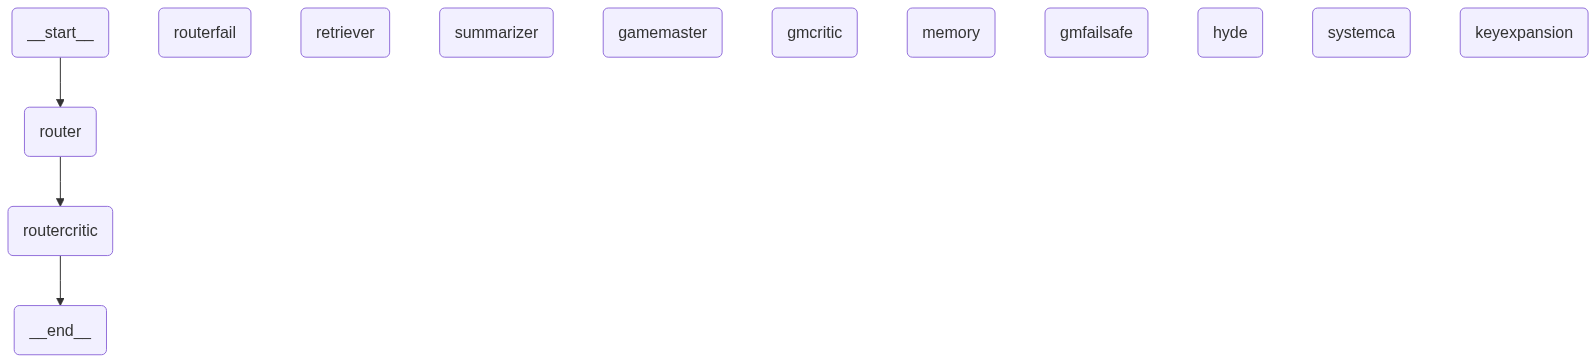

In [7]:
app = workflow.compile()
app

## Independent Tests

### Test Queries

In [ ]:
queries = [ 
    "Tell me about downtime.",
    "Tell me about dwarves",
    "Tell me about sneak attacks",
    "Tell me about flashbacks in dnd",
    "How does death saving throws work?",
    "Help me by whipping up an NPC, a human mage.",
    "Help me name a npc character. A powerful duke like character.",
    "Help me name a npc character. A powerful duke like character in Blades in the dark. Make sure the NPC fits the setting of game.",
    "Help me creater a playable character in dnd. We want a monk, with a lot of wisdom and intelligence that is still formidable in a fight.",
    "Can you explain how sneak attack works in Pathfinder?",
    "How does flashbacks work in Blades in the dark?",
    "How does falling damage work?",
    "How does falling damage work in DnD?"
    "tell me about lasers feelings."
]

### Full run

In [9]:
for idx, query in enumerate(queries):
    print("=-="*40)
    print(f"Test {idx+1}: \n QUERY: [{query}]\n\n")
    test_state = {
        "user_query": query,
        "recent_history": [],
        "chat_summary": "",
        "guessed_systems": [],
        "clean_query": "",
        "phase_1_retries": 0,
        "phase_1_feedback": "",
        "phase_1_passed": False,
        "retrieved_context": "",
        "draft_response": ""
    }
    
    # Run the graph and print the state changes
    for output in app.stream(test_state, stream_mode="updates"):
        for node_name, state_delta in output.items():
            print(f"\n=== FINISHED NODE: {node_name.upper()} ===")
            # Pretty-print the dictionary of changes
            for key, val in state_delta.items():
                print(f"  -> {key}: {val}")
    
    
    print("=-="*40)
    print("\n\n\n\n")

=-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-==-=
Test 1: 
 QUERY: [Tell me about downtime.]




KeyboardInterrupt: 

## Complete Architecture Test

Done with LLM as a Judge.

In [10]:
golden_dataset = [
    {
        "query_type": "Resource Management (Blades in the Dark)",
        "question": "How much stress does a flashback cost in Blades in the Dark?",
        "ground_truth_context": "The GM sets a stress cost when you activate a flashback action. * 0 Stress: An ordinary action for which you had easy opportunity. * 1 Stress: A complex action or unlikely opportunity. * 2 (or more) Stress: An elaborate action that involved special opportunities or contingencies.",
        "ideal_answer": "The GM sets the stress cost for a flashback based on the complexity and likelihood of the action. An ordinary action that you had an easy opportunity to do costs 0 Stress. A complex action or unlikely opportunity costs 1 Stress. An elaborate action involving special opportunities or contingencies costs 2 or more Stress.",
        "reference": "Blades in the Dark Rulebook, Flashback Rules"
    },
    {
        "query_type": "Core Mechanics (Lasers & Feelings)",
        "question": "How do character stats and action rolls work in Lasers & Feelings?",
        "ground_truth_context": "The rules are simple, all characters have only 1 stat. All actions are divided into 2 types of actions. Lasers: Actions based on logic, science and knowledge are Lasers actions. Feelings: Actions based on emotions, instinct and intuition feelings actions. When a character attempts a Lasers action, they want to roll under their stat and when they attempt a Feelings action they want to roll over. If a player rolls exactly on the stat value, they get a special result called Laser Feelings.",
        "ideal_answer": "All characters have only a single stat. Actions are divided into two categories: 'Lasers' (logic, science, knowledge) and 'Feelings' (emotions, instinct, intuition). When attempting a Lasers action, a player wants to roll under their stat. When attempting a Feelings action, they want to roll over their stat. Rolling the exact number grants a special 'Laser Feelings' result.",
        "reference": "Lasers & Feelings Core Rules"
    },
    {
        "query_type": "Out-of-Bounds Test (Call of Cthulhu 7e)",
        "question": "Do I understand the 'Became a Believer' rule correctly when reading Mythos books in Call of Cthulhu?",
        "ground_truth_context": "",
        "ideal_answer": "I apologize, but I currently do not have the Call of Cthulhu 7e rules indexed in my database. I am optimized for Dungeons & Dragons, Pathfinder 2e, Blades in the Dark, and Lasers & Feelings.",
        "reference": "Call of Cthulhu 7e / Out of Bounds"
    },
    {
        "query_type": "Out-of-Bounds Test (Cyberpunk RED)",
        "question": "How exactly does the damage multiplication work for the Autofire skill in Cyberpunk RED?",
        "ground_truth_context": "",
        "ideal_answer": "I apologize, but I currently do not have the Cyberpunk RED rules indexed in my database. I am optimized for Dungeons & Dragons, Pathfinder 2e, Blades in the Dark, and Lasers & Feelings.",
        "reference": "Cyberpunk RED / Out of Bounds"
    },
    
    # Custom Created Ones
    {
        "query_type": "Core Mechanics (DnD)",
        "question": "If my character is resistant to Fire damage and resistant to all magic damage, how much damage will I take from a fireball spell?",
        "ground_truth_context": "Resistance and Vulnerability. Some creatures and objects have Resistance or Vulnerability to certain damage types. If you have Resistance to a damage type, damage of that type is halved against you (round down). No Stacking. Multiple instances of Resistance or Vulnerability that affect the same damage type count as only one instance. For example, if you have Resistance to Necrotic damage as well as Resistance to all damage, Necrotic damage is reduced by half against you.",
        "ideal_answer": "You will take half damage (rounded down). Multiple instances of resistance affecting the same damage type do not stack, so having both fire resistance and a broad resistance to all magic only counts as a single instance of resistance against the fire damage from a fireball spell.",
        "reference": "Dungeons and Dragons"
    },
    {
        "query_type": "Mechanics Clarification",
        "question": "How does the Resilient Sphere spell work when protecting a creature from external damage or environmental hazards, and what are its physical limitations?",
        "ground_truth_context": "Resilient Sphere. Level 4 Abjuration (Wizard). A shimmering sphere encloses a Large or smaller creature or object within range. Nothing—not physical objects, energy, or other spell effects—can pass through the barrier, in or out... The sphere is immune to all damage, and a creature or object inside can’t be damaged by attacks or effects originating from outside, nor can a creature inside the sphere damage anything outside it. The sphere is weightless and just large enough to contain the creature or object inside. An enclosed creature can take an action to push against the sphere’s walls and thus roll the sphere at up to half the creature's Speed... A Disintegrate spell targeting the globe destroys it without harming anything inside.",
        "ideal_answer": "Resilient Sphere encloses a Large or smaller creature in an impenetrable, damage-immune barrier that blocks all physical objects, energy, and spell effects from passing in or out. The creature inside cannot be harmed by outside attacks, nor can they damage anything outside. The sphere is weightless, allowing the enclosed creature to use an action to roll it at up to half their Speed. The spell requires concentration (up to 1 minute) and can be instantly destroyed by a Disintegrate spell without harming the occupant.",
        "reference": "Dungeons and Dragons"
    },
    # {
    #     "query_type": "Mechanics Clarification",
    #     "question": "Based on official stat block rules, what are the primary combat capabilities, multiattack options, and evasive features of an Assassin?",
    #     "ground_truth_context": "Assassin. Medium or Small Humanoid, Neutral. AC 16, HP 97, Speed 30 ft. Traits: Evasion (takes no damage on a successful Dex save that normally deals half, or half on a failure, unless incapacitated). Actions: Multiattack (three attacks using Shortsword or Light Crossbow in any combination). Shortsword (+7 to hit, 1d6+4 piercing plus 5d6 poison damage and poisoned condition). Light Crossbow (+7 to hit, 1d8+4 piercing plus 6d6 poison damage). Bonus Actions: Cunning Action (Dash, Disengage, or Hide).",
    #     "ideal_answer": "An Assassin is a CR 8 combatant with 97 HP and 16 AC. They possess the Evasion trait to avoid area-of-effect damage and Cunning Action for mobility. In combat, they feature a Multiattack action allowing three strikes using either a shortsword (dealing piercing plus poison damage and inflicting the poisoned condition) or a light crossbow (dealing heavy ranged piercing and poison damage).",
    #     "reference": "Dungeons and Dragons"
    # },
    {
        "query_type": "Negative Constraint & Interaction (Pathfinder 1e)",
        "question": "I cast Time Stop. While time is frozen, can I disarm an enemy by taking their sword out of their hand, and then cast a Fireball directly targeting them before time resumes?",
        "ground_truth_context": "While the time stop is in effect, other creatures are invulnerable to your attacks and spells; you cannot target such creatures with any attack or spell. You cannot move or harm items held, carried, or worn by a creature stuck in normal time, but you can affect any item that is not in another creature's possession.",
        "ideal_answer": "No, you cannot do either of those actions. While Time Stop is in effect, other creatures are invulnerable to your attacks and spells, and you cannot target them[cite: 11]. Furthermore, you are not able to move or harm items that are currently held, carried, or worn by a creature stuck in normal time[cite: 11].",
        "reference": "Time Stop Spell Description"
    },
    {
        "query_type": "State-Dependent Modifiers (Pathfinder 1e)",
        "question": "I am currently grappling a bandit. Instead of pinning him first, I want to use my ropes to tie him up immediately. Do I take any penalties to my combat maneuver check for doing this while we are just grappling?",
        "ground_truth_context": "If you have your target pinned, otherwise restrained, or unconscious, you can use rope to tie him up. ... If you are grappling the target, you can attempt to tie him up in ropes, but doing so requires a combat maneuver check at a –10 penalty.",
        "ideal_answer": "Yes, you take a significant penalty. If you are grappling a target, you can attempt to tie them up in ropes, but doing so requires a combat maneuver check at a -10 penalty[cite: 11].",
        "reference": "Grapple Combat Maneuver Description"
    },
    {
        "query_type": "Edge Case Clarification (Pathfinder 1e)",
        "question": "My rogue is flanking a guard with the fighter. I want to knock the guard out without killing him. Can I use my dagger to do nonlethal sneak attack damage if I take the normal -4 penalty?",
        "ground_truth_context": "With a weapon that deals nonlethal damage (like a sap, whip, or an unarmed strike), a rogue can make a sneak attack that deals nonlethal damage instead of lethal damage. She cannot use a weapon that deals lethal damage to deal nonlethal damage in a sneak attack, not even with the usual -4 penalty.",
        "ideal_answer": "No, you cannot. A rogue cannot use a weapon that deals lethal damage, such as a dagger, to deal nonlethal damage in a sneak attack, even if you take the standard -4 penalty to the attack roll[cite: 10]. You must use a weapon that inherently deals nonlethal damage, like a sap or an unarmed strike, to perform a nonlethal sneak attack[cite: 10].",
        "reference": "Pathfinder Core Reference Document, Rogue"
    },
    
]

In [11]:
import json
from src.graph.graph_ragas import run_evaluation_suite
from src.env import PersistentVars
# ==========================================
# 6. Run and Export Results
# ==========================================
# if __name__ == "__main__":
#     # Run the harness
with open(PersistentVars.LOG_FILE, "a", encoding='utf-8') as log_file:
    print(f"[SYSTEM ALERT] RUNNING COMPLETE RAGAS PIPELINE......", file=log_file)
evaluation_results = run_evaluation_suite(golden_dataset, app)

# Save the output to a JSON file for analysis
with open("evaluation_results.json", "w", encoding="utf-8") as f:
    json.dump(evaluation_results, f, indent=4)
    
print("Evaluation complete! Results saved to 'evaluation_results.json'")
with open(PersistentVars.LOG_FILE, "a", encoding='utf-8') as log_file:
    print(f"[SYSTEM ALERT] RAGAS PIPELINE EXECUTED SUCCESSFULLY!", file=log_file)

Starting Evaluation Suite for 9 cases...

--- Running Test Case 1: Resource Management (Blades in the Dark) ---
  -> Executing LangGraph Pipeline...
  -> Grading Context Relevance...
  -> Grading Faithfulness...
  -> Case 1 Done! [Relevance: 0, Faithfulness: 0]

--- Running Test Case 2: Core Mechanics (Lasers & Feelings) ---
  -> Executing LangGraph Pipeline...


KeyboardInterrupt: 